## Preliminary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./UPL25_matches1.csv')

In [2]:
df.shape

(3592, 89)

In [3]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [4]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled



In [5]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [6]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

## Executive Summary

In [7]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity)

,max,mean,std
player_load,655.960600,392.415683,102.628830
top_speed_kmh,36.416300,29.580822,2.314279
distance_per_min_mmin,136.524292,87.017038,24.646851
power_score_wkg,21.988900,14.000183,4.016899
work_ratio,122.165500,72.639660,22.780474
max_acceleration_mss,10.000000,5.852622,0.634003
max_deceleration_mss,10.000000,7.166094,0.974420
acc_counts_per_min,7.110439,4.061030,1.225083
dec_counts_per_min,6.707629,3.899201,1.183214


In [8]:
summary_table_volume = df[volume_metrics].agg(['sum', 'max','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,max,mean,std
distance_km,30671.800000,13.500000,8.540000,2.430000
sprint_distance_m,3044059.670000,2894.440000,847.460000,379.360000
power_plays,217356.000000,145.000000,60.510000,23.020000
energy_kcal,3750333.340000,1771.050000,1044.080000,300.910000
impacts,22585.000000,46.000000,6.290000,4.870000
total_accelerations,1431297.000000,705.000000,398.470000,120.370000
total_decelerations,1374209.000000,656.000000,382.570000,116.220000


## Data Overview

In [9]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
7,Mbarara City Fc,30
15,Wakiso Giants Fc,28
3,Kitara Fc,27
0,Bul Fc,27
14,Vipers Sc,27
9,Police Fc,26
4,Lugazi Fc,26
2,Kcca Fc,25
13,Ura Fc,25
8,Nec Fc,24


In [10]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

,p_name,player_club_,unique_match_days
3,Abdulkarim Watambala,Vipers Sc,26
37,Ayiko Richard,Lugazi Fc,25
116,Francis Odongo,Mbarara City Fc,25
274,Nelson Senkatuka,Soltilo Bright Stars Fc,25
324,Ronald Otti,Kitara Fc,25
320,Rogers Ochaki Torach,Vipers Sc,25
337,Seiri Arigumaho,Mbarara City Fc,24
152,Hilary Panuel Mukundane,Vipers Sc,24
13,Ali Arshavin Bayo,Lugazi Fc,24
15,Allan Okello,Vipers Sc,24


In [11]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
5,Maroons Fc,11.208333
15,Wakiso Giants Fc,11.173913
13,Ura Fc,10.960000
7,Mbarara City Fc,10.793103
4,Lugazi Fc,10.758621
8,Nec Fc,10.720000
3,Kitara Fc,10.444444
1,Express Fc,10.250000
14,Vipers Sc,9.892857
12,Updf Fc,9.629630


In [12]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
7,Mbarara City Fc,29
4,Lugazi Fc,29
14,Vipers Sc,28
11,Soltilo Bright Stars Fc,28
9,Police Fc,27
12,Updf Fc,27
3,Kitara Fc,27
2,Kcca Fc,26
13,Ura Fc,25
8,Nec Fc,25


C:\Users\Travail\AppData\Local\Temp\ipykernel_1584\1326583913.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])


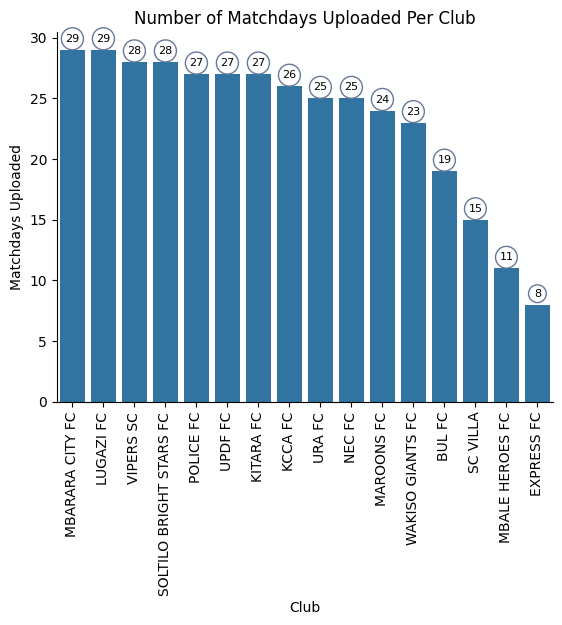

In [13]:
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)
sns.barplot(data=data, x='club_for', y='unique_matchdays')
plt.xticks(rotation=90)
plt.title('Number of Matchdays Uploaded Per Club')
plt.xlabel('Club')
plt.ylabel('Matchdays Uploaded')

# Annotate values at the top of each bar
for i, value in enumerate(data['unique_matchdays']):
    plt.text(
        i, value + 0.5, str(value),
        ha='center', va='bottom',
        fontsize=8,
        bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#667898', facecolor='white', linewidth=1)
    )

# Remove the top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set xticklabels to uppercase
ax.set_xticklabels([label.get_text().upper() for label in ax.get_xticklabels()])

plt.show()

In [14]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 31)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

,match_day,total_player_entries
0,Md1,120
11,Md2,145
22,Md3,143
24,Md4,146
25,Md5,147
26,Md6,149
27,Md7,134
28,Md8,145
29,Md9,96
1,Md10,132


In [15]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'Md{i}' for i in range(1, 31)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


,match_day,num_clubs
0,Md1,14
11,Md2,16
22,Md3,15
24,Md4,15
25,Md5,16
26,Md6,16
27,Md7,13
28,Md8,16
29,Md9,10
1,Md10,14


In [16]:

def plot_line_with_values(data, x_col, y_col, title=None, x_label=None,y_label=None, figsize=(10, 6)):
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the line
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)

    
    # Get current axis
    ax = plt.gca()
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set spine and tick colors to light gray
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)
    

    if x_col == 'match_day':
        # Ensure match_day is ordered as per matchday_order
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(md).replace('Md', 'MD ') for md in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90)
        # Re-plot with sorted data to ensure correct order
        
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
        
    # Add value labels above each point
    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}', 
            (x, y),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )
    
    # Set title
    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)

    # #start the y-axis at 0
    ax.set_ylim(bottom=60,top=180)  # Adjust the top limit as needed
    

    # Set labels
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    # Adjust layout
    plt.tight_layout()
    
    return ax

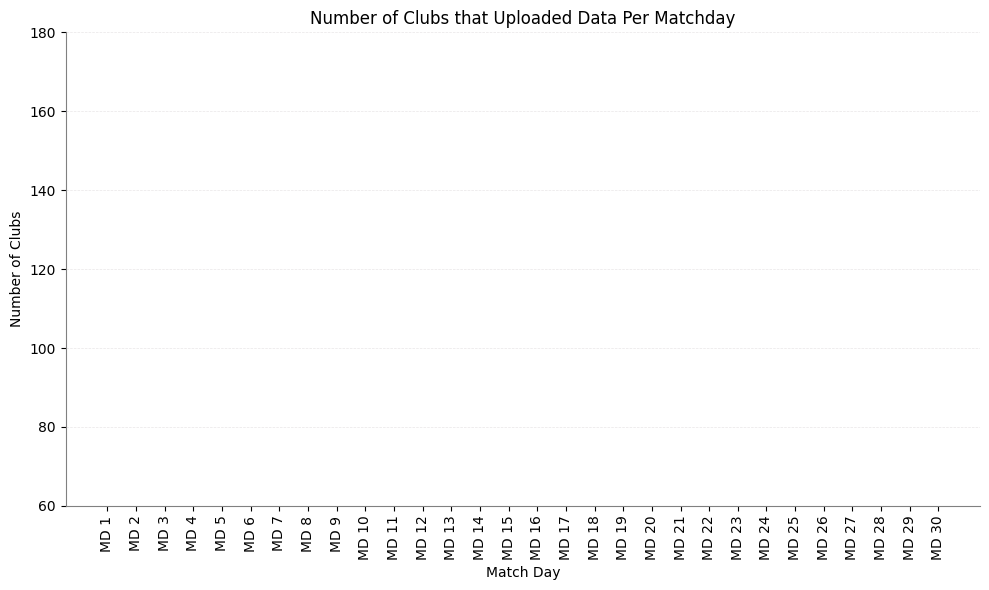

In [17]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Number of Clubs that Uploaded Data Per Matchday',x_label='Match Day', y_label='Number of Clubs');

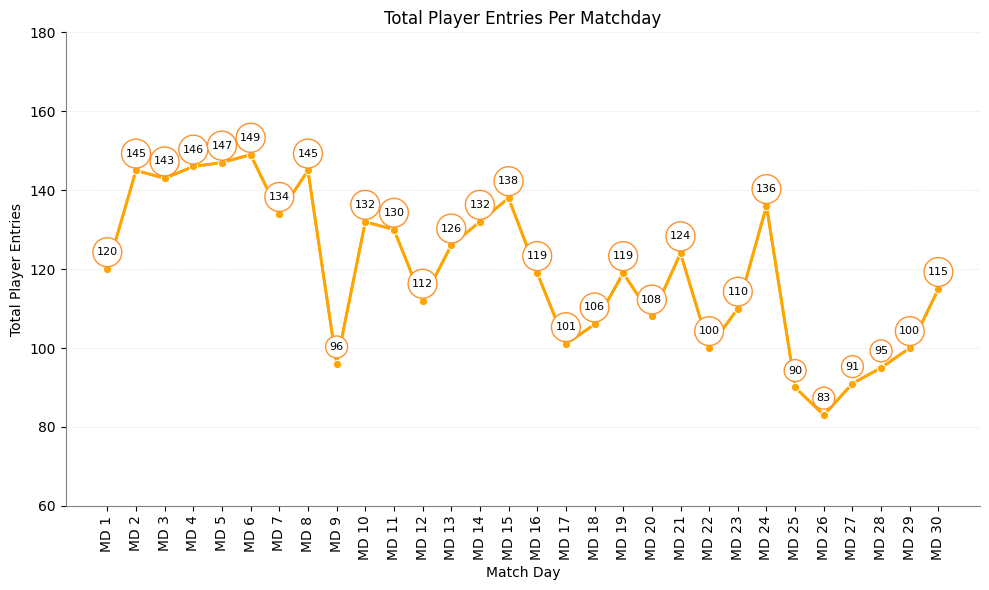

In [18]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [19]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,location,count,percentage
0,Away,1855,51.642539
1,Home,1737,48.357461


In [20]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,result,count,percentage
0,Loss,1325,36.887528
1,Win,1267,35.272829
2,Draw,1000,27.839644


In [21]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Vipers Sc,19,6,3
Nec Fc,15,5,5
Ura Fc,14,2,9
Kcca Fc,12,7,7
Maroons Fc,10,5,9
Kitara Fc,9,9,9
Mbarara City Fc,8,8,13
Lugazi Fc,7,9,13
Updf Fc,7,8,12


### Max Metrics

In [22]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

,max,mean,std
top_speed_kmh,36.416300,29.580822,2.314279
distance_per_min_mmin,136.524292,87.017038,24.646851
max_acceleration_mss,10.000000,5.852622,0.634003
max_deceleration_mss,10.000000,7.166094,0.974420


In [23]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

,sum,max,mean,std
distance_in_speed_zone_1_km,3015250.700000,2099.000000,839.440000,243.100000
distance_in_speed_zone_2_km,14971900.700000,6290.400000,4168.120000,1205.710000
distance_in_speed_zone_3_km,9640575.300000,6135.200000,2683.900000,998.360000
distance_in_speed_zone_4_km,2634255.200000,2349.500000,733.370000,317.050000
distance_in_speed_zone_5_km,409803.500000,643.600000,114.090000,94.240000


## Analysis

### Club Comparison

In [24]:
club_volume_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
club_volume_mean.round(2)
style_table_for_docs(club_volume_mean)


,club_for,avg_distance_km,avg_sprint_distance_m,avg_power_plays,avg_energy_kcal,avg_impacts,avg_total_accelerations,avg_total_decelerations
0,Sc Villa,10.086886,1080.263981,72.126376,1221.870866,7.131587,449.715000,428.014444
1,Soltilo Bright Stars Fc,9.704213,862.143439,64.896820,1164.405773,7.851212,447.380439,432.345644
2,Kcca Fc,9.117836,1000.611918,69.973506,1116.806316,5.741976,427.647525,409.698496
3,Maroons Fc,9.007664,980.269357,68.178226,1109.227100,4.849710,420.601710,404.935301
4,Bul Fc,8.894690,778.056201,57.985870,1126.760822,5.784067,417.803385,399.762999
5,Vipers Sc,8.867177,919.170262,65.189906,1084.968068,8.050488,414.407243,396.613944
6,Express Fc,8.770577,884.550661,64.241231,1090.391743,6.670733,445.518654,426.662169
7,Police Fc,8.605027,799.521327,57.794077,1064.720558,6.851908,406.279099,391.086138
8,Ura Fc,8.561664,881.111558,61.741490,1042.197994,5.471507,407.705661,391.742913
9,Wakiso Giants Fc,8.407495,811.190198,58.519765,1018.706431,7.403448,389.918279,376.113744


In [25]:
club_intensity_mean = (
    df.groupby(['club_for', 'match_day'])[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_work_ratio', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_mean)

,club_for,avg_player_load,avg_power_score_wkg,avg_work_ratio,avg_acc_counts_per_min,avg_dec_counts_per_min
0,Sc Villa,456.488766,16.521405,88.427938,4.579135,4.356419
1,Soltilo Bright Stars Fc,453.127819,15.713335,81.829293,4.550860,4.398021
2,Kcca Fc,408.456675,14.955091,78.625811,4.317860,4.136784
3,Maroons Fc,411.400553,14.962113,78.488633,4.325050,4.164129
4,Express Fc,419.483847,14.411045,74.298349,4.486373,4.296817
5,Bul Fc,403.108979,14.326917,73.620771,4.210155,4.029277
6,Mbarara City Fc,391.754241,13.738329,72.952407,4.087759,3.932918
7,Ura Fc,392.628714,14.016739,72.532409,4.148828,3.986525
8,Lugazi Fc,381.267064,13.800766,72.081063,4.012825,3.832416
9,Vipers Sc,409.698832,14.336240,71.921206,4.131580,3.953673


In [26]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin', 'max_acceleration_mss', 'max_deceleration_mss']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max)

,club_for,max_top_speed_kmh,max_distance_per_min_mmin,max_max_acceleration_mss,max_max_deceleration_mss
0,Bul Fc,36.416300,123.209469,7.711200,10.000000
1,Ura Fc,36.224300,128.651725,10.000000,10.000000
2,Lugazi Fc,36.208300,126.420948,9.724500,10.000000
3,Nec Fc,36.016300,127.241957,9.814200,10.000000
4,Sc Villa,36.016300,136.524292,7.496400,10.000000
5,Vipers Sc,35.840300,121.878974,7.937100,10.000000
6,Mbarara City Fc,35.728300,124.947769,10.000000,10.000000
7,Kcca Fc,35.568300,126.309864,8.464700,10.000000
8,Kitara Fc,35.296300,124.065330,9.093400,9.809000
9,Maroons Fc,35.136300,128.552486,7.795600,10.000000


### Player High Scores

In [27]:
# For each metric in volume_metrics, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Ronald Ssekiganda,Sc Villa,13.499000,Md7
1,sprint_distance_m,Innocent Wafula Esimu,Mbarara City Fc,2894.443000,Md1
2,power_plays,Innocent Wafula Esimu,Mbarara City Fc,145.000000,Md1
3,energy_kcal,Amos Etoju,Mbale Heroes Fc,1771.047900,Md11
4,impacts,Blanchar Mulamba,Wakiso Giants Fc,46.000000,Md13
5,total_accelerations,Felix Okot,Maroons Fc,705.000000,Md29
6,total_decelerations,Felix Okot,Maroons Fc,656.000000,Md29
7,player_load,Felix Okot,Maroons Fc,655.960600,Md29
8,top_speed_kmh,Yafeesi Mubiru,Bul Fc,36.416300,Md11
9,distance_per_min_mmin,Ronald Ssekiganda,Sc Villa,136.524292,Md1


In [28]:
df[df['dec_counts_per_min'] == (df['dec_counts_per_min'].max())]['p_name']

1164    Frank Tumwesigye
Name: p_name, dtype: object

### Comparison by Position Group

In [29]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defender,9.050000,852.620000,60.160000,1111.110000,6.020000,430.090000,413.270000
Forward,7.590000,876.080000,58.300000,931.960000,7.450000,337.060000,323.830000
Midfielder,8.720000,817.400000,62.780000,1057.100000,5.650000,411.710000,394.710000


In [30]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defender,415.805009,14.766578,77.056398,4.373351,4.202145
Forward,351.255837,12.584946,62.146052,3.447049,3.312377
Midfielder,398.656000,14.260142,76.086456,4.198015,4.024803


In [31]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defender,35.840000,127.680000,6.580000,6.490000
Forward,36.420000,127.680000,6.270000,6.150000
Midfielder,36.220000,136.520000,7.110000,6.710000


In [32]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defender,29.840000,91.980000,4.370000,4.200000
Forward,30.570000,77.580000,3.450000,3.310000
Midfielder,28.450000,88.930000,4.200000,4.020000


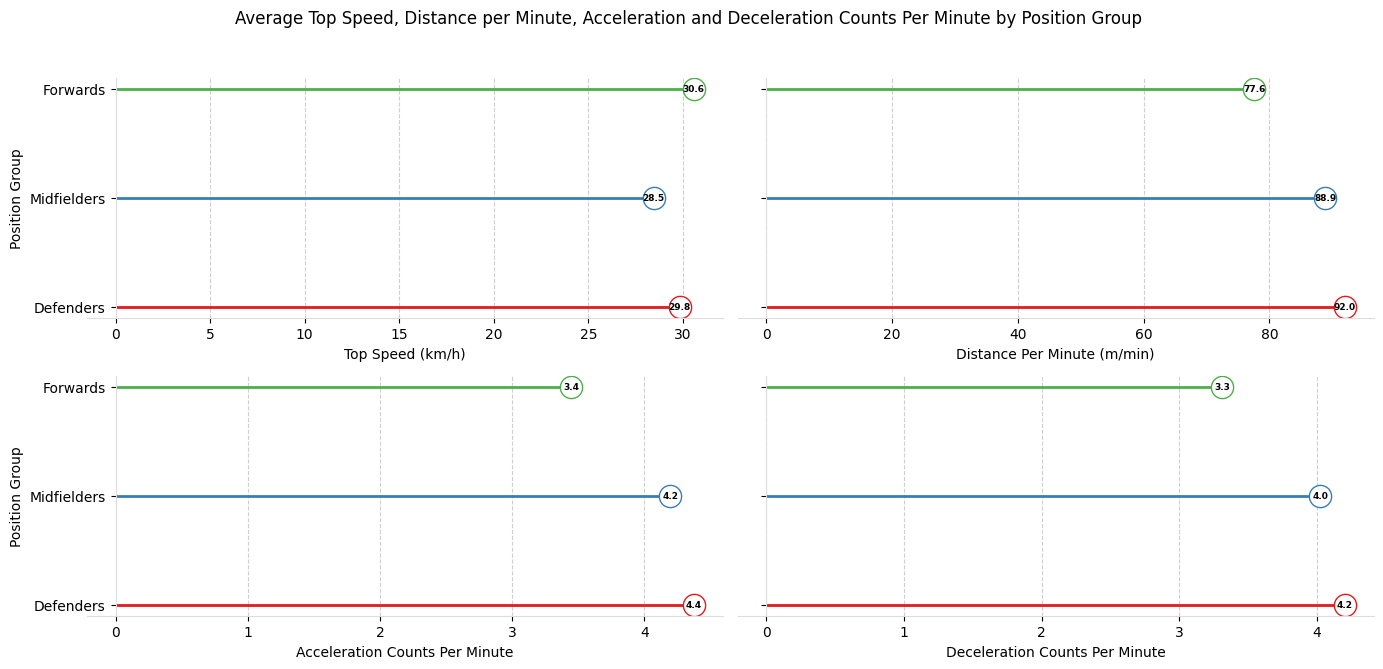

In [33]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

# Define the order of position groups
position_order = ['Defender', 'Midfielder', 'Forward']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 16

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'top_speed_kmh':
            text_val = f'{val:.1f}'
        elif metric == 'distance_per_min_mmin':
            text_val = f'{val:.1f}'
        elif metric == 'acc_counts_per_min':
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.1f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=6.5, color='black', fontweight='bold')

    yticklabels = [f"{pos}s" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Top Speed, Distance per Minute, Acceleration and Deceleration Counts Per Minute by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


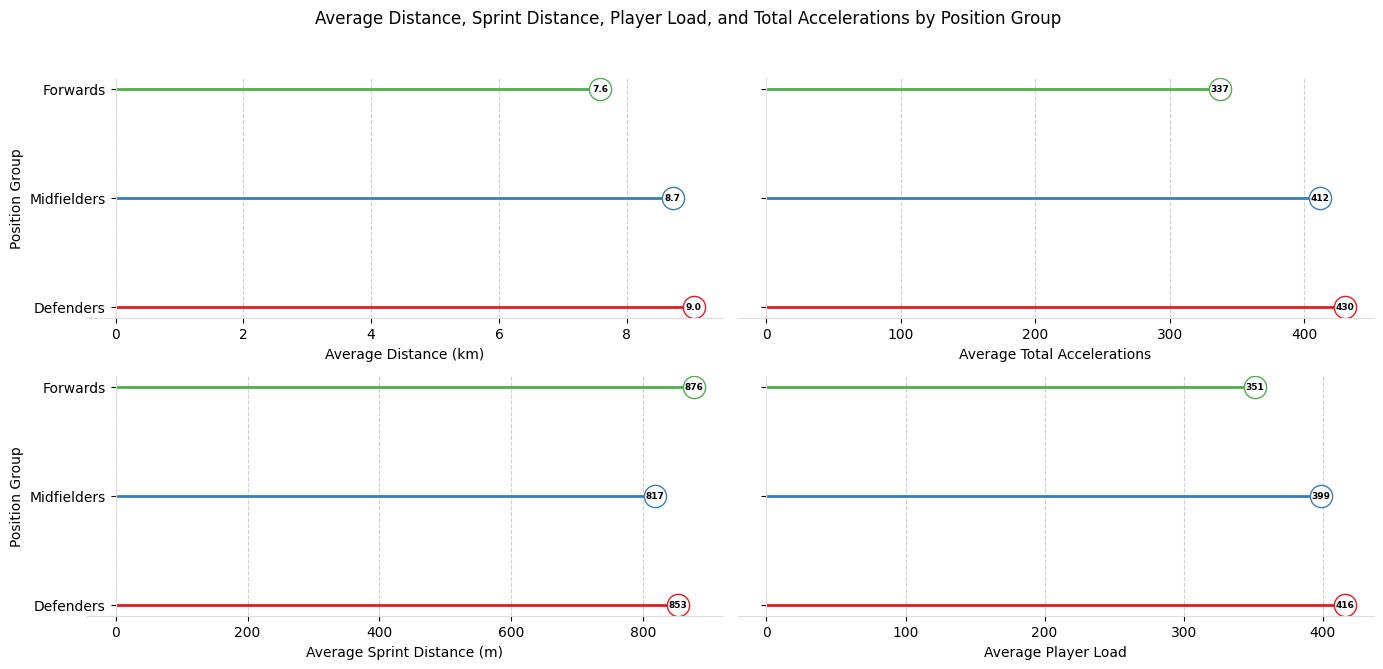

In [34]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

# Define the order of position groups
position_order = ['Defender', 'Midfielder', 'Forward']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 16

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=6.5, color='black', fontweight='bold')

    yticklabels = [f"{pos}s" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Distance, Sprint Distance, Player Load, and Total Accelerations by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Comparison by Location

In [35]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
location,,,,,,,
Away,8.500000,840.480000,60.300000,1039.150000,6.240000,398.140000,382.340000
Home,8.580000,854.910000,60.740000,1049.340000,6.330000,398.810000,382.820000


In [36]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_location)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
location,,,,,
Away,391.110584,13.939831,72.425354,4.056297,3.895412
Home,393.809442,14.064635,72.868524,4.066085,3.903248


In [37]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].mean().round(2)
style_table_for_docs(avg_intensity_by_location_)

,top_speed_kmh,distance_per_min_mmin
location,,
Away,29.540000,86.590000
Home,29.620000,87.480000


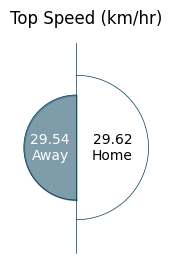

In [38]:
# Prepare data
home_speed = avg_intensity_by_location_.loc['Home', 'top_speed_kmh']
away_speed = avg_intensity_by_location_.loc['Away', 'top_speed_kmh']

# Make radius proportional to top speed (e.g., scale so max speed gets max_radius, min gets min_radius)
min_radius = 0.8
max_radius = 1.1
speeds = np.array([home_speed, away_speed])
norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
home_radius, away_radius = norm_radii

color = '#003b59'

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
ax.axis('off')

# Draw right (Home) semicircle: theta from -pi/2 to pi/2, center at (0,0)
theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
x_home = home_radius * np.cos(theta_home)
y_home = home_radius * np.sin(theta_home)
ax.plot(x_home, y_home, color=color, linewidth=0.5)
if home_radius < away_radius:
    ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

# Draw left (Away) semicircle: theta from pi/2 to 3pi/2, center at (0,0)
theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
x_away = away_radius * np.cos(theta_away)
y_away = away_radius * np.sin(theta_away)
ax.plot(x_away, y_away, color=color, linewidth=0.5)
if away_radius < home_radius:
    ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

# Draw the separating line (y from -max_radius to +max_radius at x=0)
ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

# Place values inside semicircles, centered
ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')
ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')

plt.title('Top Speed (km/hr)', fontsize=12)
plt.show()


### Metric Distribution 

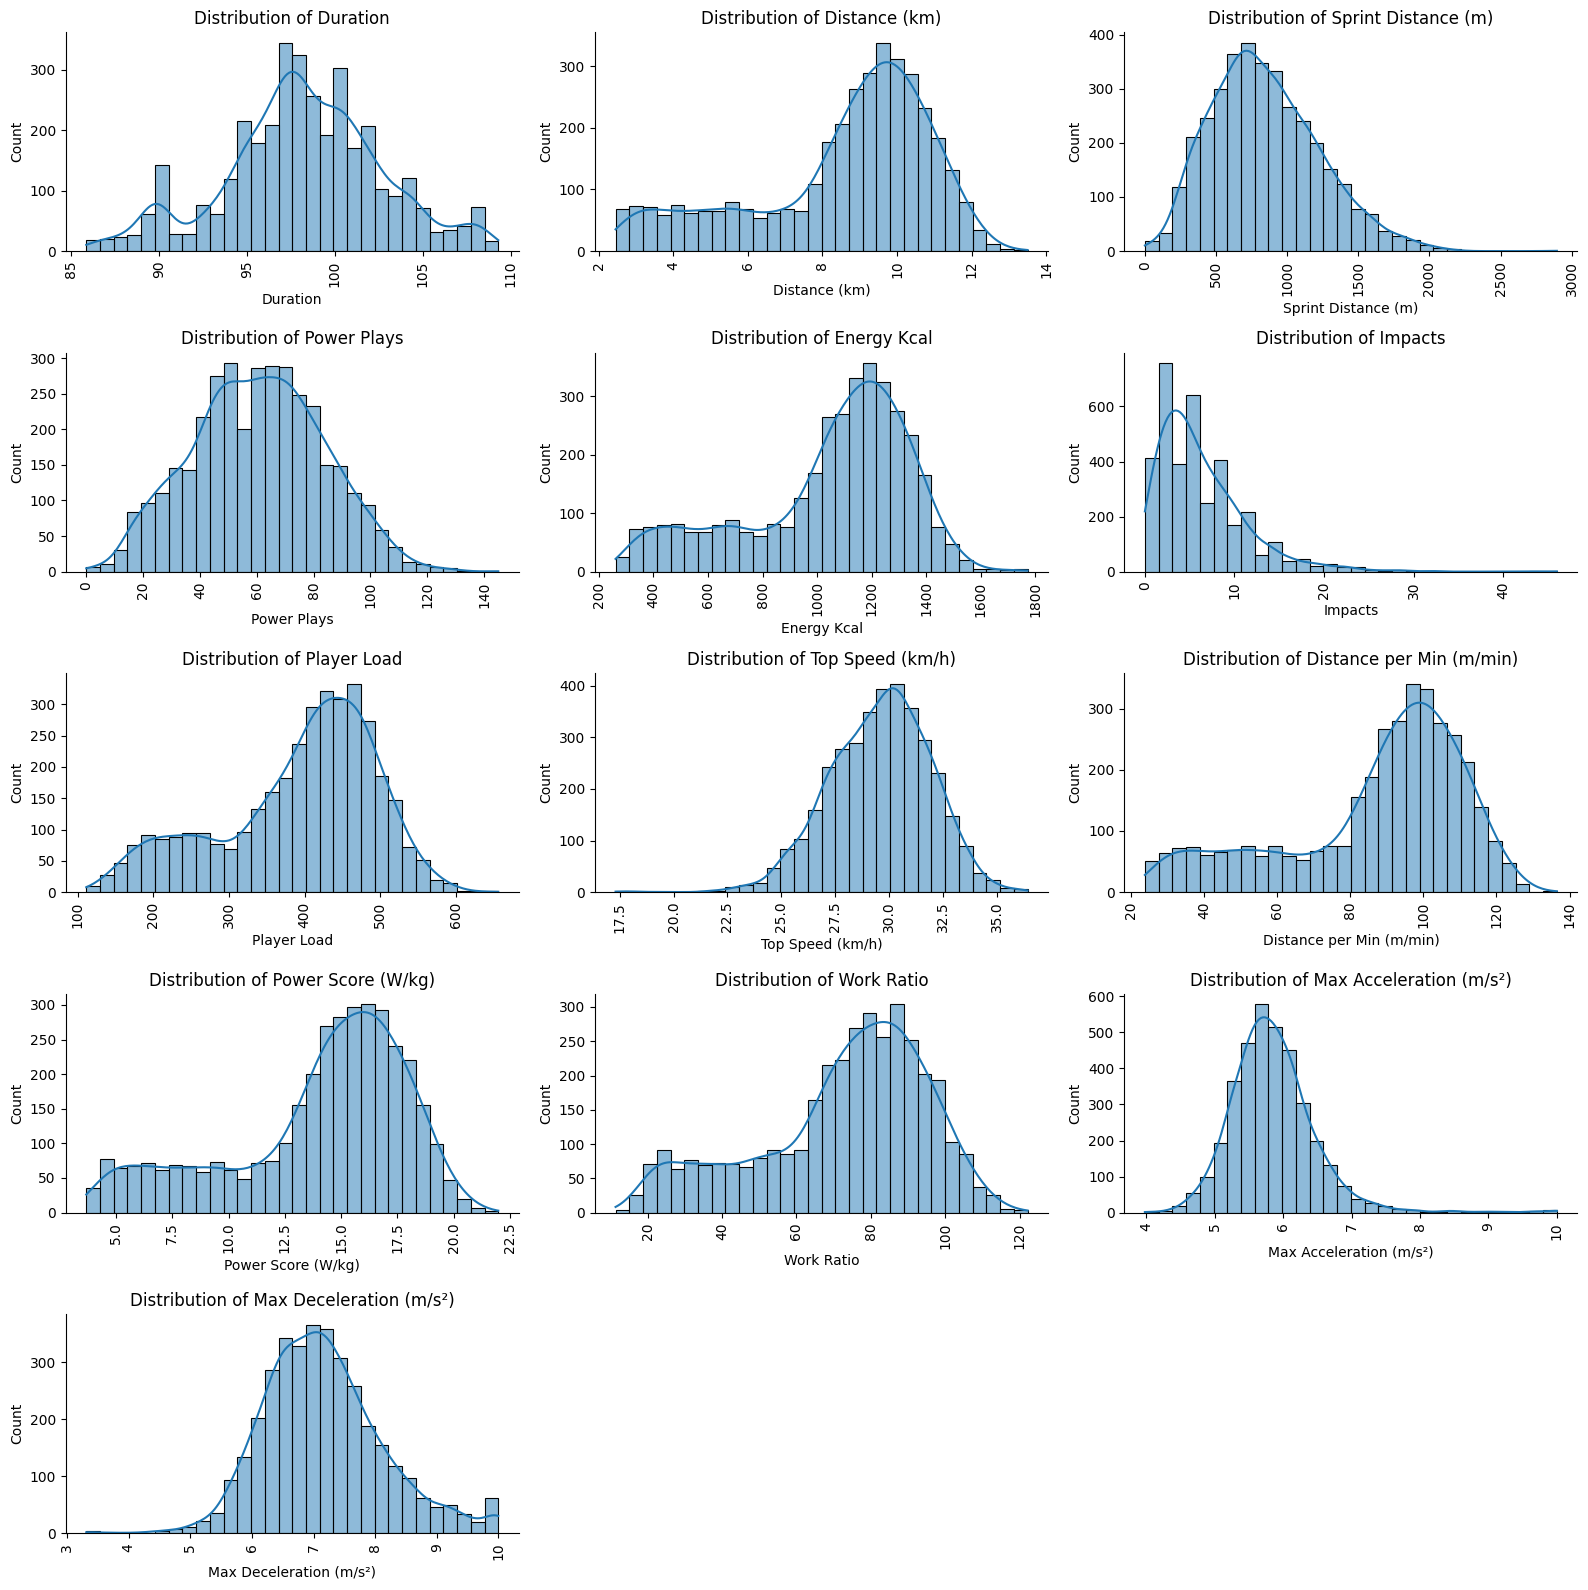

In [39]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    # Format title and x-label: replace _ with space, capitalize, add units if present
    label = col.replace('_', ' ').title()
    # Add units for specific columns
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'max_acceleration_mss':
        label = 'Max Acceleration (m/s²)'
    elif col == 'max_deceleration_mss':
        label = 'Max Deceleration (m/s²)'
    elif col == 'acc_counts_per_min':
        label = 'Acc. Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Dec. Counts per Min'
    
    plt.title(f'Distribution of {label}')
    plt.xlabel(label)
    plt.xticks(rotation=90)
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



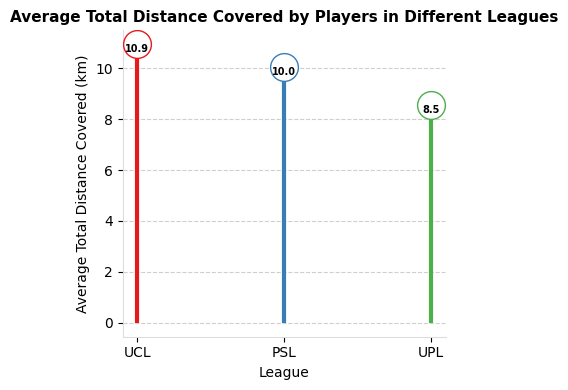

In [40]:
# Comparative bar graph for three leagues using vertical lines with large circles on top

leagues = [ 'UCL','PSL', 'UPL']
values = [ 10.94,10.045, 8.54]
palette = sns.color_palette('Set1', len(leagues))
circle_radius = 20

fig, ax = plt.subplots(figsize=(4, 4))

# Draw vertical lines for each league
for i, (league, val, color) in enumerate(zip(leagues, values, palette)):
    ax.vlines(i, 0, val, color=color, linewidth=3, zorder=2)
    ax.plot(i, val, 'o', markeredgecolor=color, markerfacecolor='white', markersize=circle_radius, zorder=3)
    ax.text(i, val, f'{val:.1f}', va='top', ha='center', fontweight='bold',fontsize=7, color='black')

ax.set_xticks(range(len(leagues)))
ax.set_xticklabels(leagues)
ax.set_ylabel('Average Total Distance Covered (km)')
ax.set_xlabel('League')
ax.set_title('Average Total Distance Covered by Players in Different Leagues', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E0DCDD')
ax.spines['bottom'].set_color('#E0DCDD')
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)
plt.tight_layout()
plt.show()

## Trend Analysis

In [41]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.980000,956.910000,67.080000,1103.220000,7.070000,423.170000,406.520000,414.300000,29.590000,91.040000,14.780000,76.870000,5.920000,7.270000,4.290000,4.120000
11,Md2,8.820000,941.030000,65.680000,1075.690000,6.430000,403.030000,387.200000,403.980000,29.870000,89.550000,14.470000,74.440000,5.950000,7.130000,4.090000,3.930000
22,Md3,9.050000,874.160000,63.380000,1103.640000,6.770000,435.710000,419.100000,417.160000,29.850000,91.250000,14.690000,76.780000,5.890000,7.180000,4.400000,4.230000
24,Md4,8.810000,857.120000,61.640000,1077.280000,7.270000,421.980000,405.790000,405.540000,29.730000,89.080000,14.400000,74.620000,5.840000,7.180000,4.270000,4.100000
25,Md5,9.030000,904.580000,65.560000,1108.020000,6.890000,435.030000,418.340000,416.540000,29.600000,91.650000,14.800000,77.160000,5.840000,7.080000,4.410000,4.250000
26,Md6,8.520000,814.260000,57.540000,1039.290000,6.170000,392.110000,375.760000,392.490000,29.660000,86.470000,13.780000,71.980000,5.920000,7.220000,3.980000,3.810000
27,Md7,8.550000,864.710000,61.250000,1043.690000,5.760000,394.790000,378.900000,389.500000,29.650000,86.050000,13.810000,72.250000,5.800000,7.330000,3.970000,3.810000
28,Md8,8.720000,903.570000,63.010000,1070.010000,6.820000,409.250000,393.030000,400.890000,29.770000,87.380000,14.120000,72.740000,5.770000,7.360000,4.100000,3.940000
29,Md9,8.780000,883.800000,60.620000,1078.820000,6.230000,413.890000,395.650000,398.480000,29.490000,89.390000,14.390000,74.280000,5.750000,7.160000,4.220000,4.030000
1,Md10,8.740000,835.570000,62.480000,1074.640000,6.670000,416.730000,400.690000,400.980000,29.580000,89.820000,14.510000,75.240000,5.880000,7.240000,4.280000,4.120000


In [42]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,Md1,8.980000,956.910000,67.080000,1103.220000,7.070000,423.170000,406.520000,414.300000,29.590000,91.040000,14.780000,76.870000,5.920000,7.270000,4.290000,4.120000
1,Md2,8.900000,948.970000,66.380000,1089.460000,6.750000,413.100000,396.860000,409.140000,29.730000,90.300000,14.630000,75.660000,5.930000,7.200000,4.190000,4.030000
2,Md3,8.950000,924.030000,65.380000,1094.180000,6.750000,420.640000,404.280000,411.810000,29.770000,90.610000,14.650000,76.030000,5.920000,7.190000,4.260000,4.090000
3,Md4,8.890000,890.770000,63.570000,1085.540000,6.820000,420.240000,404.030000,408.890000,29.820000,89.960000,14.520000,75.280000,5.890000,7.170000,4.250000,4.090000
4,Md5,8.960000,878.620000,63.530000,1096.320000,6.980000,430.900000,414.410000,413.080000,29.730000,90.660000,14.630000,76.190000,5.860000,7.150000,4.360000,4.190000
5,Md6,8.790000,858.650000,61.580000,1074.860000,6.780000,416.370000,399.960000,404.860000,29.660000,89.070000,14.330000,74.590000,5.870000,7.160000,4.220000,4.050000
6,Md7,8.700000,861.180000,61.450000,1063.670000,6.280000,407.310000,391.000000,399.510000,29.640000,88.060000,14.130000,73.800000,5.850000,7.210000,4.120000,3.960000
7,Md8,8.600000,860.850000,60.600000,1051.000000,6.250000,398.720000,382.570000,394.290000,29.690000,86.630000,13.910000,72.320000,5.830000,7.300000,4.020000,3.850000
8,Md9,8.680000,884.030000,61.630000,1064.170000,6.270000,405.970000,389.190000,396.290000,29.640000,87.610000,14.110000,73.090000,5.780000,7.290000,4.100000,3.930000
9,Md10,8.740000,874.310000,62.040000,1074.490000,6.570000,413.290000,396.460000,400.120000,29.610000,88.860000,14.340000,74.090000,5.800000,7.250000,4.200000,4.030000


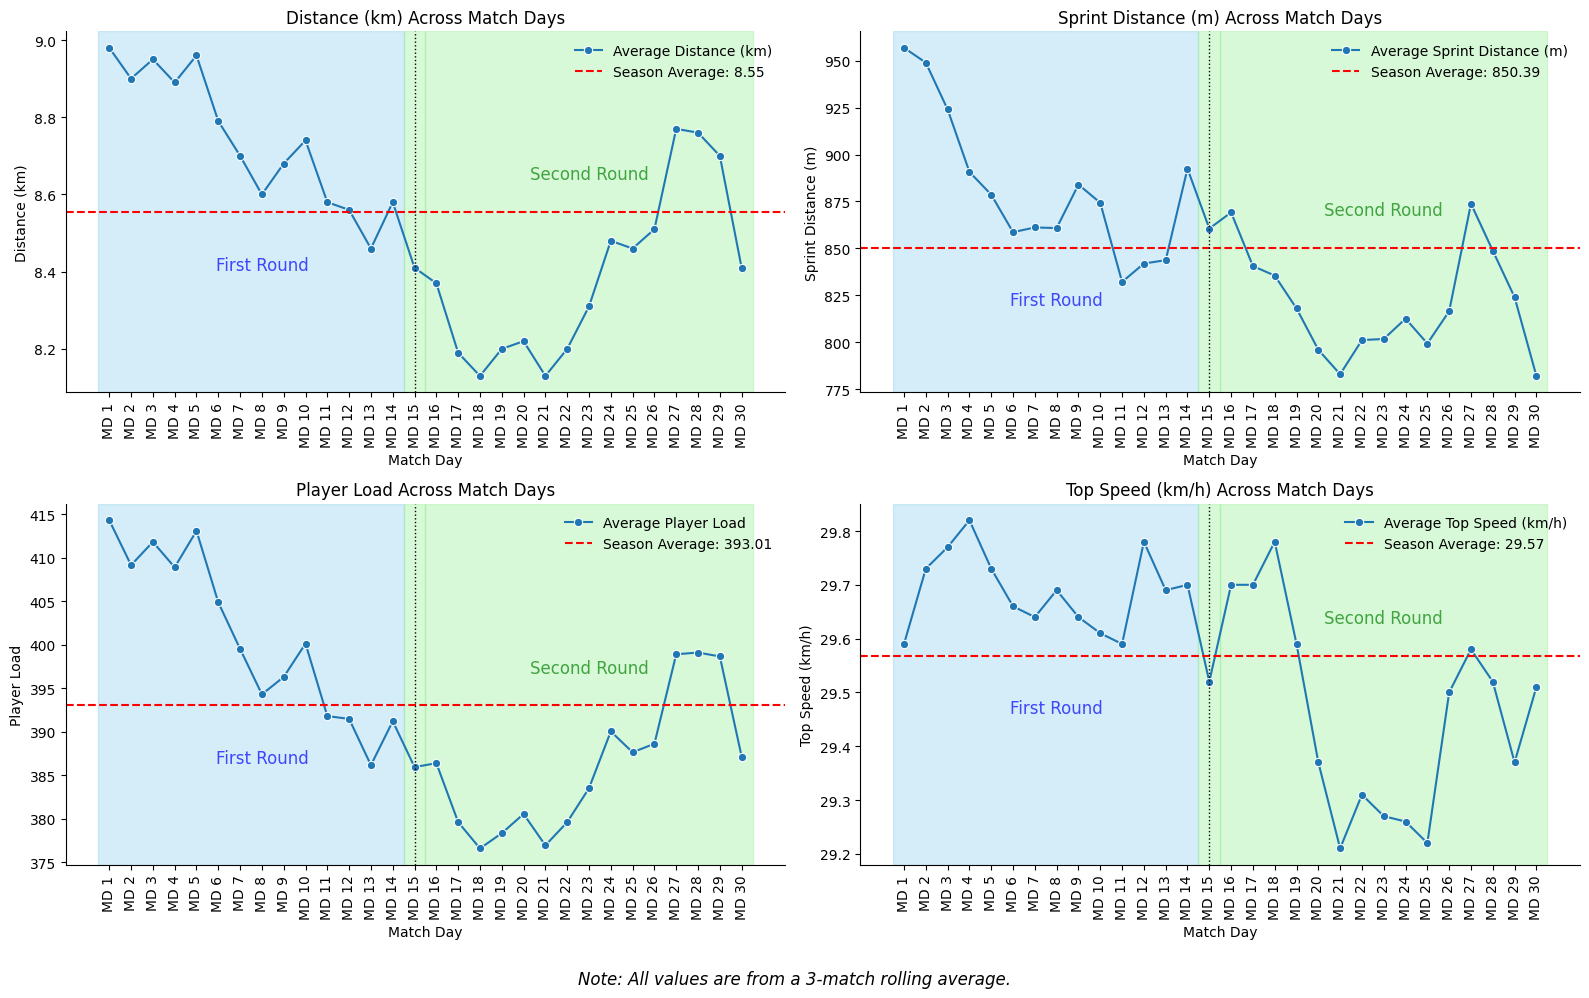

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('distance_km', 'Distance (km)'),
    ('sprint_distance_m', 'Sprint Distance (m)'),
    ('player_load', 'Player Load'),
    ('top_speed_kmh', 'Top Speed (km/h)')
]

md15_idx = matchday_order.index('Md15')

for ax, (col, label) in zip(axes.flatten(), metrics):
    sns.lineplot(
        data=rolling_avg,
        x='match_day',
        y=col,
        marker='o',
        ax=ax,
        label=f'Average {label}'
    )
    avg_value = rolling_avg[col].mean()
    ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
    # Draw vertical line at MD15
    ax.axvline(md15_idx, color='black', linestyle=':', linewidth=1)
    # Shade area before MD15 (First Round)
    ax.axvspan(-0.5, md15_idx - 0.5, color='skyblue', alpha=0.35)
    # Shade area after and including MD15 (Second Round)
    ax.axvspan(md15_idx - 0.5, md15_idx + 0.5, color='lightgreen', alpha=0.35)
    ax.axvspan(md15_idx + 0.5, len(matchday_order) - 0.5, color='lightgreen', alpha=0.35)
    xticklabels = [str(md).replace('Md', 'MD ') for md in rolling_avg['match_day']]
    ax.set_xticks(range(len(rolling_avg['match_day'])))
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(f'{label} Across Match Days')
    ax.set_xlabel('Match Day')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = ax.legend(frameon=False)
    ymin, ymax = ax.get_ylim()
    ax.text(md15_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
    ax.text(md15_idx + (len(matchday_order)-md15_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
plt.show()


## Correlation Analysis

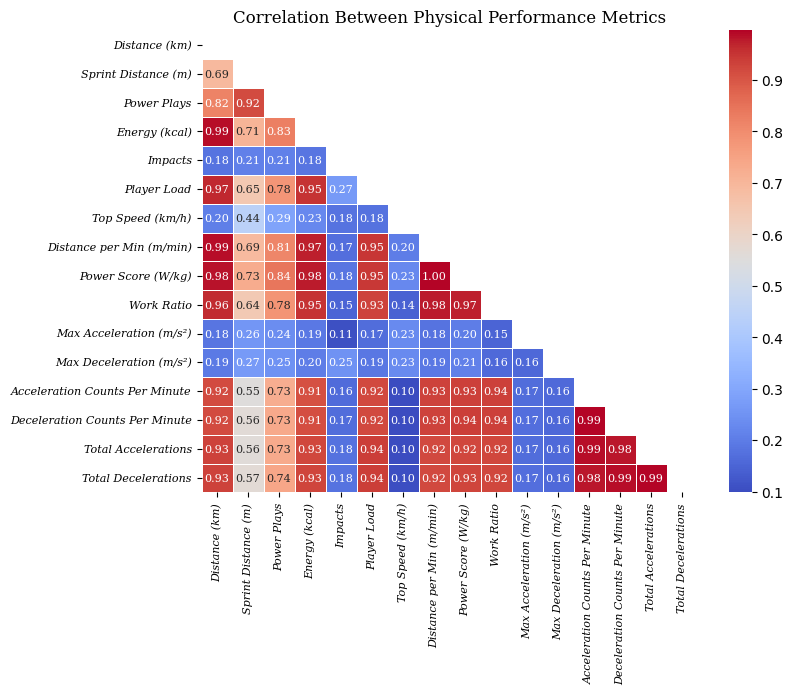

In [44]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acceleration Counts Per Minute',
    'dec_counts_per_min':'Deceleration Counts Per Minute',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    annot_kws={"fontsize":8, "fontfamily":"serif"}
)
plt.title("Correlation Between Physical Performance Metrics", fontsize=12, fontfamily="serif")
plt.xticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.yticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.show()


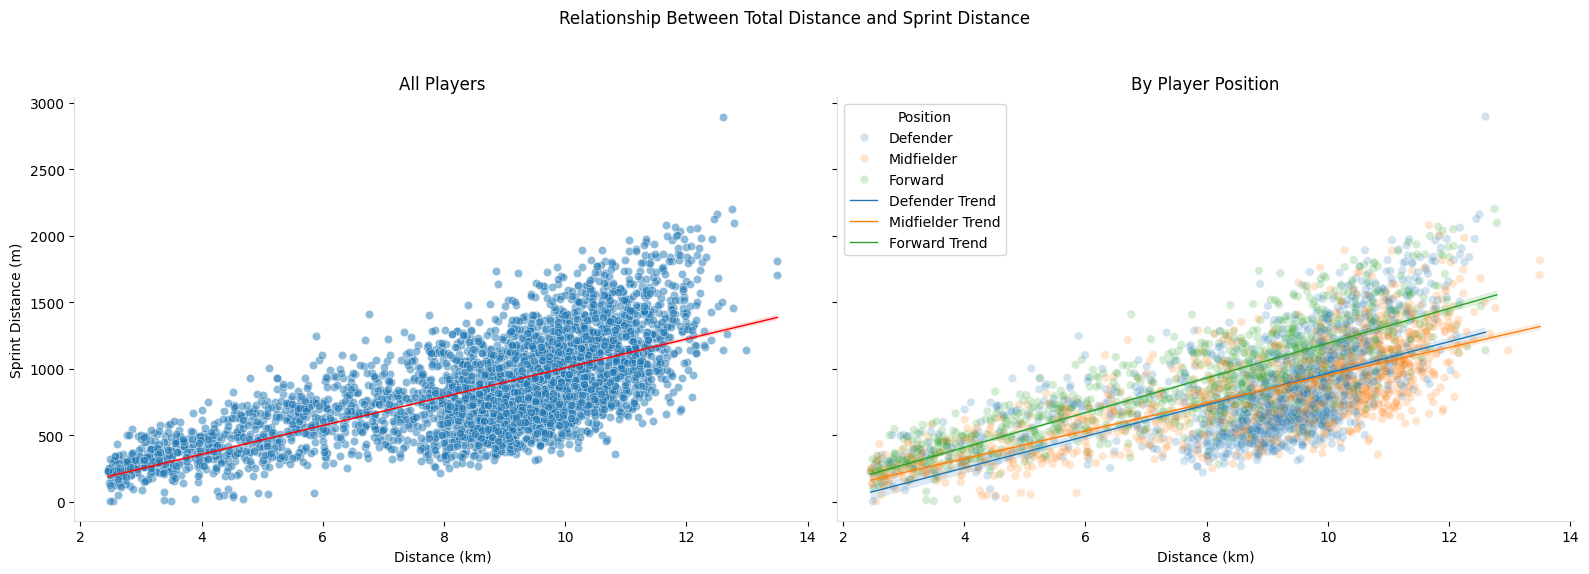

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: All players, no hue
ax1 = axes[0]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', alpha=0.5, ax=ax1)
sns.regplot(data=df, x='distance_km', y='sprint_distance_m', scatter=False, ax=ax1, color='red', line_kws={'linewidth':1})
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Sprint Distance (m)')
ax1.set_title('All Players')
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')

# Plot 2: Hue by player position, trend lines for each group
ax2 = axes[1]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', hue='general_position', alpha=0.2, ax=ax2)
for pos in df['general_position'].dropna().unique():
    sns.regplot(
        data=df[df['general_position'] == pos],
        x='distance_km',
        y='sprint_distance_m',
        scatter=False,
        ax=ax2,
        label=f"{pos} Trend",
        line_kws={'linewidth':1}
    )
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Sprint Distance (m)')
ax2.set_title('By Player Position')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.legend(title='Position')

plt.suptitle('Relationship Between Total Distance and Sprint Distance')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [46]:
df[df['p_name'] == 'Brian Nkuubi'].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,11.0,97.834848,3.371601,93.816667,96.400000,96.933333,98.883333,106.266667
distance_km,11.0,10.239109,2.593766,2.603100,10.407800,10.989000,11.284900,12.065600
sprint_distance_m,11.0,1049.014545,264.467277,433.118000,980.834000,1014.799000,1165.071000,1428.996000
power_plays,11.0,82.090909,22.042933,21.000000,79.500000,91.000000,93.000000,102.000000
energy_kcal,11.0,1235.483745,314.254983,313.990900,1257.169000,1317.676700,1373.918350,1462.840400
...,...,...,...,...,...,...,...,...
time_in_speed_zone_5_secs,11.0,7.654545,3.480047,2.100000,6.250000,7.500000,8.850000,14.800000
total_accelerations,11.0,446.454545,125.383702,109.000000,425.000000,455.000000,531.500000,565.000000
total_decelerations,11.0,438.181818,122.068684,108.000000,421.500000,441.000000,511.500000,559.000000
acc_counts_per_min,11.0,4.567922,1.303166,1.127586,4.305859,4.706664,5.507058,5.852901


In [47]:
df[df['p_name'] == 'Bashir Mutanda'].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,5.0,96.773333,1.666067,94.916667,95.850000,96.500000,97.283333,99.316667
distance_km,5.0,5.516540,2.033102,3.513700,4.464200,4.582600,6.373900,8.648300
sprint_distance_m,5.0,350.357600,121.810832,203.935000,250.304000,369.561000,434.788000,493.200000
power_plays,5.0,26.400000,9.939819,17.000000,19.000000,25.000000,29.000000,42.000000
energy_kcal,5.0,681.701200,249.053857,434.832600,557.708000,570.036900,776.492000,1069.436500
...,...,...,...,...,...,...,...,...
time_in_speed_zone_5_secs,5.0,5.160000,2.373394,2.600000,3.600000,5.100000,5.700000,8.800000
total_accelerations,5.0,250.000000,77.035706,176.000000,204.000000,226.000000,271.000000,373.000000
total_decelerations,5.0,239.400000,73.108139,166.000000,195.000000,220.000000,262.000000,354.000000
acc_counts_per_min,5.0,2.574907,0.748288,1.823834,2.128326,2.381036,2.785678,3.755664


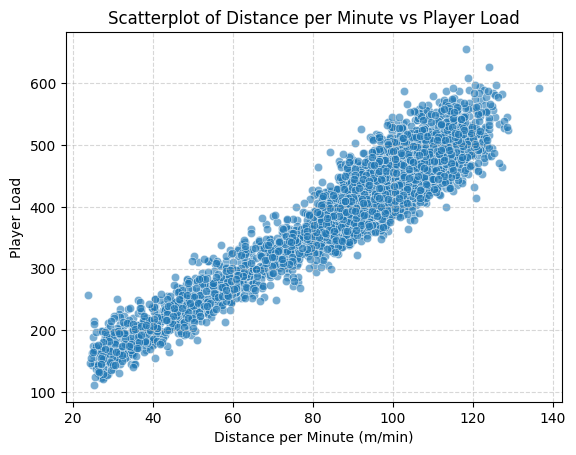

In [48]:
sns.scatterplot(data=df, x='distance_per_min_mmin', y='player_load', alpha=0.6)
plt.xlabel('Distance per Minute (m/min)')
plt.ylabel('Player Load')
plt.title('Scatterplot of Distance per Minute vs Player Load')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()